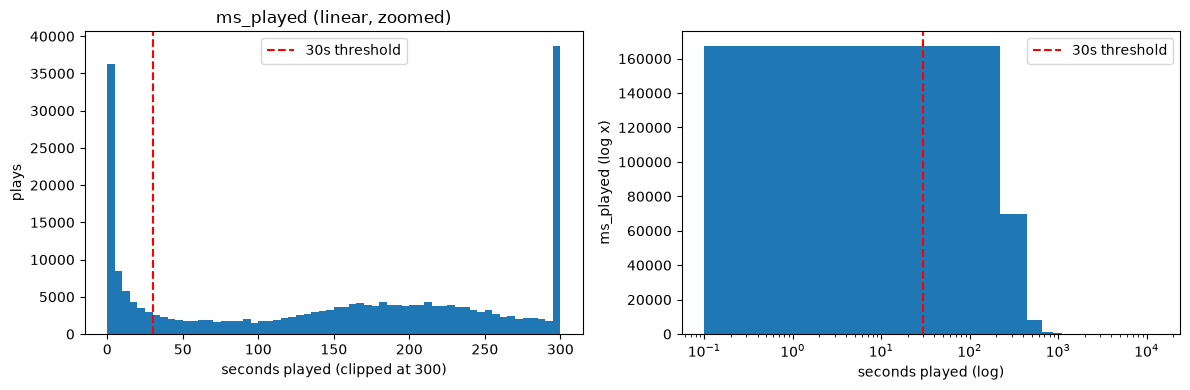

In [2]:
import matplotlib.pyplot as plt
from alys import config
from pathlib import Path
import pandas as pd

# work from phase 1 output. Fall back to the committed sample
# so that the notebook still runs on a fresh clone that hasn't
# built the private data

interim = config.INTERIM_DIR / "plays.parquet"
sample = config.SAMPLE_DIR / "plays_sample.parquet"
path = interim if interim.exists() else sample

plays = pd.read_parquet(path)

threshold_ms = config.MIN_LISTEN_MS  # 30,000

# ms_played is very right-skewed, i.e. very few long plays
# So: look at it in 2 ways: (1) raw seconds (zoomed to first few min)
# and (2) log-scale for a long tail
seconds = plays["ms_played"] / 1000

fig, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(12, 4))

# linear view, zoomed to 0-300 s where the "did I listen" data sits
ax_lin.hist(seconds.clip(upper=300), bins=60)
ax_lin.axvline(threshold_ms / 1000, color="red", linestyle="--", label="30s threshold")
ax_lin.set_xlabel("seconds played (clipped at 300)")
ax_lin.set_ylabel("plays")
ax_lin.set_title("ms_played (linear, zoomed)")
ax_lin.legend()

# log view to see the whole tale
# this way the near-zero spike doesn't swamp it
ax_log.hist(seconds.clip(lower=0.1), bins=60)
ax_log.set_xscale("log")
ax_log.axvline(threshold_ms / 1000, color="red", linestyle="--", label="30s threshold")
ax_log.set_xlabel("seconds played (log)")
ax_log.set_ylabel("ms_played (log x)")
ax_log.legend()

fig.tight_layout()
plt.show()

In [3]:
below = (plays["ms_played"] < threshold_ms).mean()
print(f"{below:.1%} of plays fall below the 30s threshold")
print(plays["ms_played"].div(1000).describe()) # summary stats, in seconds

24.8% of plays fall below the 30s threshold
count    247691.000000
mean        171.275713
std         164.087375
min           0.000000
25%          31.038000
50%         165.250000
75%         245.680500
max       13209.999000
Name: ms_played, dtype: float64


`ms_played` is bimodal: a large spike of sub-5 s plays (skips) and a hump of full-length song plays, separated by a low-density valley. 30s threshold sits in that valley, & so separates skips from real listens (24.8% below); its exact position is not sensitive.

In [5]:
figpath = config.PROJECT_ROOT / "reports" / "figures" / "2026_08_05_ms_played_distribution.png"
figpath.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figpath, dpi=150, bbox_inches="tight")
print("saved", figpath)

saved /Users/michael/code/mr/alys/reports/figures/2026_08_05_ms_played_distribution.png


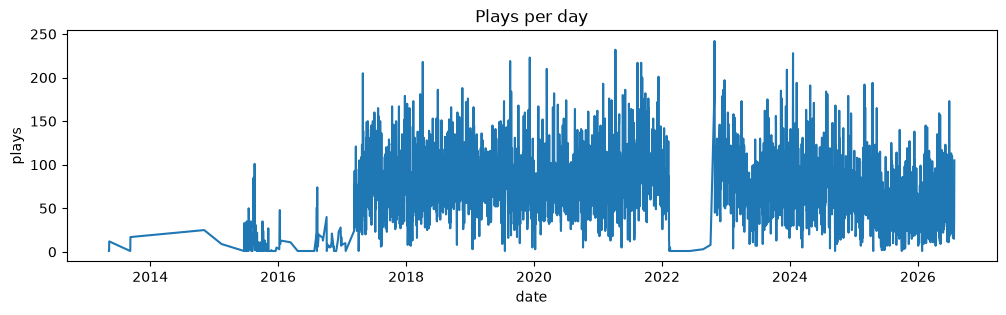

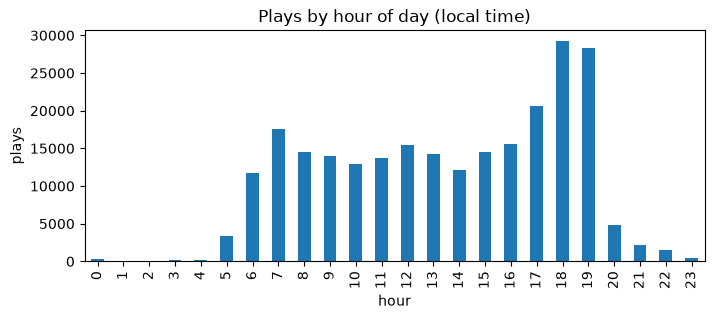

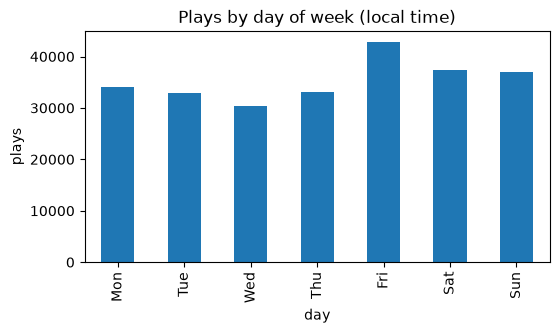

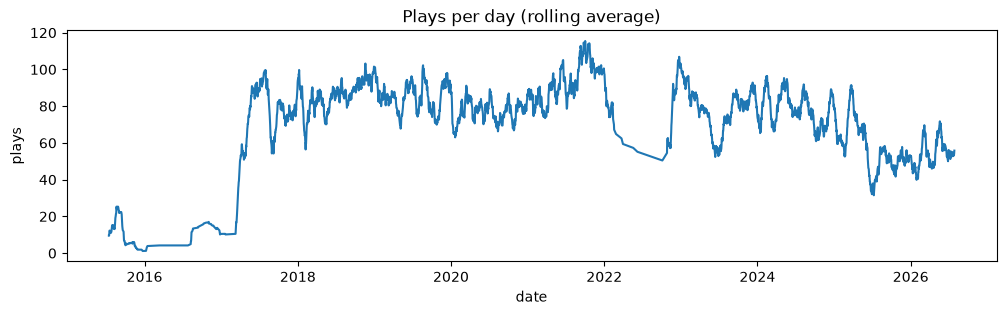

In [12]:
# set the timezone to where I actually, you know, listen
local = plays["ts"].dt.tz_convert("America/Los_Angeles")

# derive clock from local time
day = local.dt.date  # calendar day
hour = local.dt.hour # 0-23
dow = local.dt.dayofweek # Mon=0 .... Sun=6
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

# plays per day over the whole history
per_day = plays.groupby(day).size()
fig, ax = plt.subplots(figsize=(12, 3))
per_day.plot(ax=ax)
ax.set_title("Plays per day")
ax.set_xlabel("date")
ax.set_ylabel("plays")
plt.show()

# plays by hour of day
by_hour = plays.groupby(hour).size().reindex(range(24), fill_value=0)
fix, ax = plt.subplots(figsize=(8, 3))
by_hour.plot(kind="bar", ax=ax)
ax.set_title("Plays by hour of day (local time)")
ax.set_xlabel("hour")
ax.set_ylabel("plays")
plt.show()

# plays by day of week
by_dow = plays.groupby(dow).size().reindex(range(7), fill_value=0)
by_dow.index = dow_labels
fix, ax = plt.subplots(figsize=(6, 3))
by_dow.plot(kind="bar", ax=ax)
ax.set_title("Plays by day of week (local time)")
ax.set_xlabel("day")
ax.set_ylabel("plays")
plt.show()

# plays per day rolling
per_day = plays.groupby(day).size()
fig, ax = plt.subplots(figsize=(12, 3))
per_day.rolling(30).mean().plot(ax=ax)
ax.set_title("Plays per day (rolling average)")
ax.set_xlabel("date")
ax.set_ylabel("plays")
plt.show()

In 2022, following Neil Young's example, I went off Spotify, using Youtube Music for some months (YT Music is also a pretty great service.) But I think I went back mainly because it was clear Joe Rogan wasn't going anywhere. 

For "hour of day," I tend to play a lot during dinner and cleanup, the hours between 6PM and 8PM. Since 2025 I've tended to listen less, opting for different formats, like Bandcamp, vinyl, CD, and sometimes Youtube. 

In [13]:
figpath = config.PROJECT_ROOT / "reports" / "figures" / "2026_08_05_plays_per_day_rolling_average.png"
figpath.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figpath, dpi=150, bbox_inches="tight")
print("saved", figpath)

saved /Users/michael/code/mr/alys/reports/figures/2026_08_05_plays_per_day_rolling_average.png


artist_name
The Beatles                         3812
Johann Sebastian Bach               3115
Paul McCartney                      1765
The Kinks                           1742
David Bowie                         1721
Prince                              1620
Harold Budd                         1332
The Rolling Stones                  1285
The Police                          1261
XTC                                 1063
Brian McBride                       1056
Brian Eno                           1017
The Who                             1001
Roxy Music                           890
Chihei Hatakeyama                    874
Bing & Ruth                          866
Elvis Costello & The Attractions     860
Pye Corner Audio                     815
New Order                            813
Talking Heads                        787
Name: count, dtype: int64
----------
track_name                                        artist_name             
Mélodrames télégraphiés (In B Major 7th), Part 1  Brian 

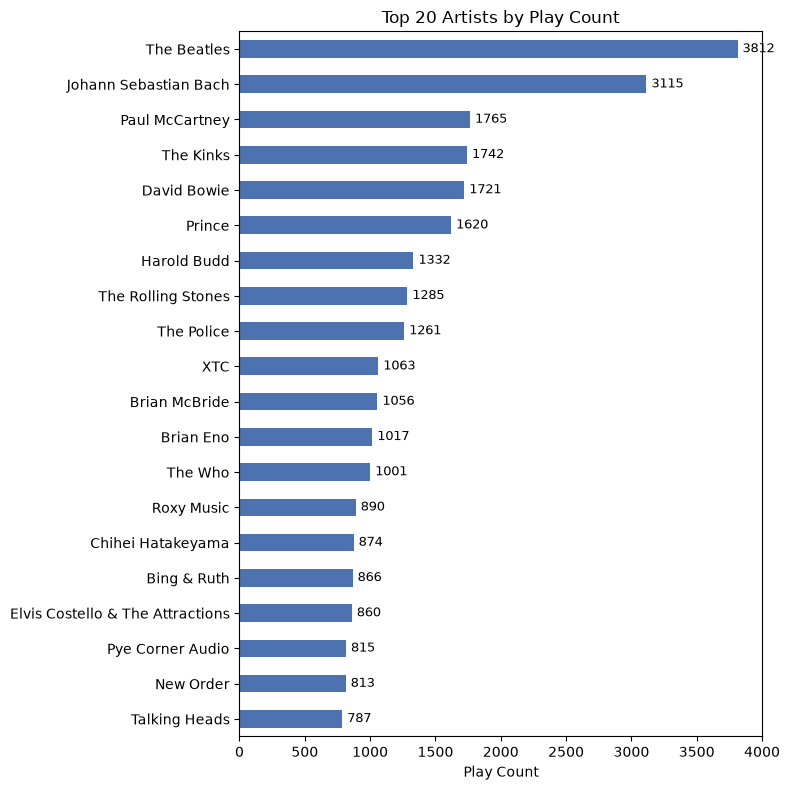

In [22]:
# top-N tables
top_artists = plays["artist_name"].value_counts().head(20)
top_tracks = plays.groupby(["track_name", "artist_name"]).size().sort_values(ascending=False).head(20)
top_albums = plays["album_name"].value_counts().head(20)

print(top_tracks)
print('-'*10)
print(top_albums)

# render top artists as a chart
fig, ax = plt.subplots(figsize=(8, 8))
top_artists.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")

ax.set_xlabel("Play Count")
ax.set_ylabel("")
ax.set_title("Top 20 Artists by Play Count")

# add value labels at the end of each bar
for i, v in enumerate(top_artists.sort_values()):
    ax.text(v + max(top_artists)*0.01, i, str(v), va="center", fontsize=9)

plt.tight_layout()
plt.show()

In [23]:
figpath = config.PROJECT_ROOT / "reports" / "figures" / "2026_08_06_top_twenty_artists.png"
figpath.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figpath, dpi=150, bbox_inches="tight")
print("saved", figpath)

saved /Users/michael/code/mr/alys/reports/figures/2026_08_06_top_twenty_artists.png


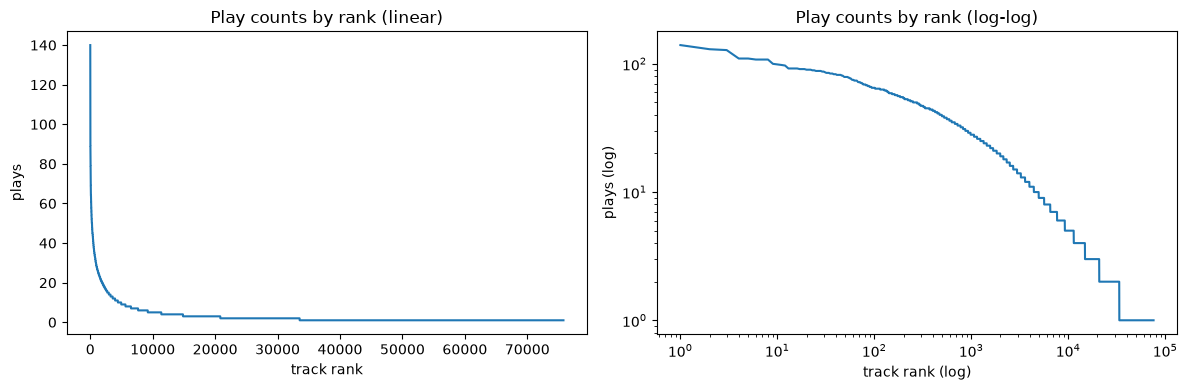

In [16]:
# long-tail curve over tracks (the classic version)
track_counts = plays["track_uri"].value_counts().sort_values(ascending=False)
ranks = range(1, len(track_counts) + 1)

fig, (ax_lin, ax_log) = plt.subplots(1, 2, figsize=(12, 4))

# linear rank curve: the dramatic "head then long flat tail" slope
ax_lin.plot(ranks, track_counts.values)
ax_lin.set_xlabel("track rank")
ax_lin.set_ylabel("plays")
ax_lin.set_title("Play counts by rank (linear)")

# log-log: power lw shows up as approximately straight line here
ax_log.loglog(ranks, track_counts.values)
ax_log.set_xlabel("track rank (log)")
ax_log.set_ylabel("plays (log)")
ax_log.set_title("Play counts by rank (log-log)")

fig.tight_layout()
plt.show()

In [21]:
figpath = config.PROJECT_ROOT / "reports" / "figures" / "2026_08_06_play_counts_by_rank_log_log.png"
figpath.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figpath, dpi=150, bbox_inches="tight")
print("saved", figpath)

saved /Users/michael/code/mr/alys/reports/figures/2026_08_06_play_counts_by_rank_log_log.png


In [17]:
total = track_counts.sum()
cum = track_counts.cumsum() / total

for frac in [0.5, 0.8, 0.9]:
    n_tracks = (cum < frac).sum() + 1
    print(f"{frac:.0%} of all plays come from the top {n_tracks:,} tracks"
         f"({n_tracks / len(track_counts):.1%}) of the catalog")

# how much of the catalog did I play exactly once?
once = (track_counts == 1).mean()
print(f"{once:.1%} of the tracks were played only once")

50% of all plays come from the top 7,050 tracks(9.3%) of the catalog
80% of all plays come from the top 29,889 tracks(39.4%) of the catalog
90% of all plays come from the top 51,022 tracks(67.3%) of the catalog
55.8% of the tracks were played only once


In [20]:
# what about the non-skips?
meaningfuls = plays[plays["meaningful_listen"]]
# top-N tables
top_artists = meaningfuls["artist_name"].value_counts().head(20)
top_tracks = meaningfuls.groupby(["track_name", "artist_name"]).size().sort_values(ascending=False).head(20)
top_albums = meaningfuls["album_name"].value_counts().head(20)

print(top_artists)

print('-'*10)
print(top_tracks)

print('-'*10)
print(top_albums)

artist_name
The Beatles              3272
Johann Sebastian Bach    2908
The Kinks                1407
Paul McCartney           1398
David Bowie              1262
Harold Budd              1211
Prince                   1060
The Rolling Stones        967
Brian McBride             938
Chihei Hatakeyama         824
The Police                820
Bing & Ruth               796
Brian Eno                 764
The Who                   755
Pye Corner Audio          729
Celer                     686
Roedelius                 683
XTC                       678
Loscil                    658
Wes Montgomery            620
Name: count, dtype: int64
----------
track_name                                             artist_name        
Mélodrames télégraphiés (In B Major 7th), Part 1       Brian McBride          123
Antarctica                                             Windy & Carl           111
raining for hours                                      ame                    100
Chukhung                      